In [14]:
# Credit Risk Score Modeling
## 1. Data Loading and Preprocessing

import pandas as pd
import matplotlib.pyplot as plt

In [15]:
columns = [
   "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

df = pd.read_csv("data/german.data",
                 sep = r"\s+",
                 header = None, 
                 names = columns)
df.head(10)

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
5,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1
6,A14,24,A32,A42,2835,A63,A75,3,A93,A101,...,A122,53,A143,A152,1,A173,1,A191,A201,1
7,A12,36,A32,A41,6948,A61,A73,2,A93,A101,...,A123,35,A143,A151,1,A174,1,A192,A201,1
8,A14,12,A32,A43,3059,A64,A74,2,A91,A101,...,A121,61,A143,A152,1,A172,1,A191,A201,1
9,A12,30,A34,A40,5234,A61,A71,4,A94,A101,...,A123,28,A143,A152,2,A174,1,A191,A201,2


In [16]:
# Inspect and clean the data
df.shape

(1000, 21)

In [17]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_status          1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment               1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [21]:
df["credit_risk"].value_counts()

credit_risk
1    700
2    300
Name: count, dtype: int64

In [22]:
df["default"] = df["credit_risk"].map({
    1: 0,
    2: 1
})
df[["credit_risk", "default"]].head(10)
df["default"].value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [ ]:
## 2. Exploratory Data Analysis (EDA)

## 3. Credit Amount vs. Default Risk

df.groupby("default")["credit_amount"].mean()

default
0    2985.457143
1    3938.126667
Name: credit_amount, dtype: float64

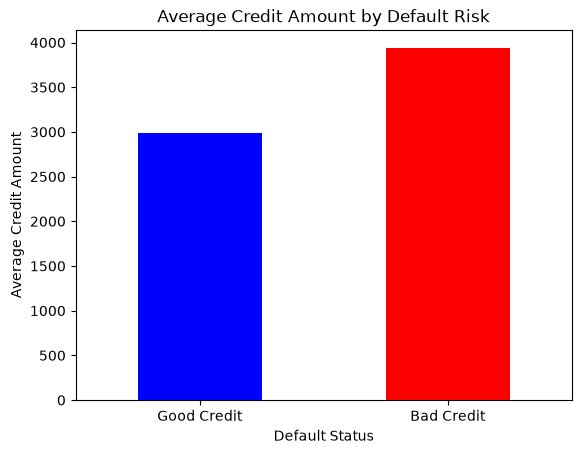

In [31]:
avg_credit = df.groupby("default")["credit_amount"].mean()

avg_credit.plot(kind="bar", color=["blue", "red"])

plt.title("Average Credit Amount by Default Risk")
plt.xlabel("Default Status")
plt.ylabel("Average Credit Amount")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [32]:
df.groupby("default")["duration"].mean()

default
0    19.207143
1    24.860000
Name: duration, dtype: float64

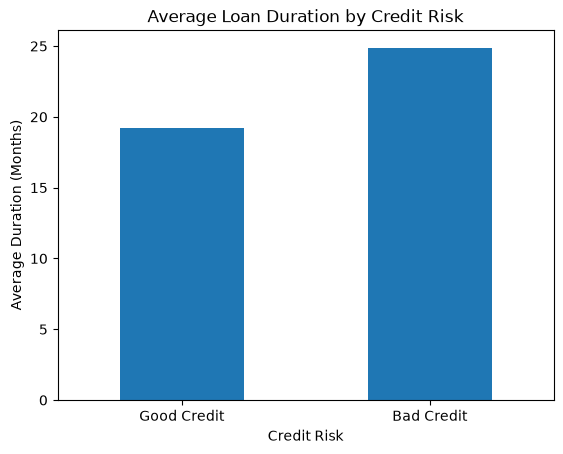

In [33]:
avg_duration = df.groupby("default")["duration"].mean()

avg_duration.plot(kind="bar")

plt.title("Average Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Average Duration (Months)")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [34]:
df.groupby("default")["age"].mean()

default
0    36.224286
1    33.963333
Name: age, dtype: float64

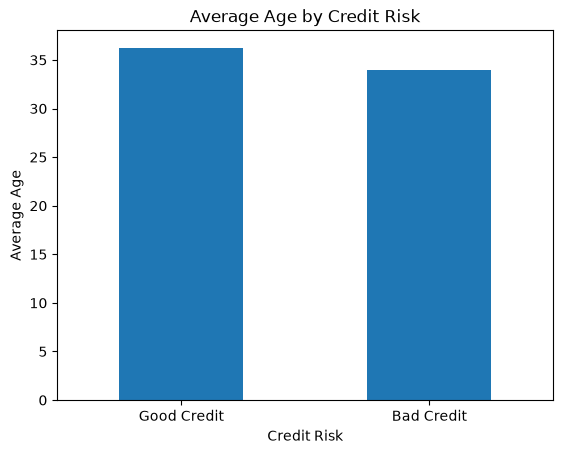

In [35]:
avg_age = df.groupby("default")["age"].mean()

avg_age.plot(kind="bar")

plt.title("Average Age by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Average Age")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [36]:
#4 — Checking Account Status vs Credit Risk

df["checking_status"].value_counts()

checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

In [37]:
df.groupby("checking_status")["default"].mean()

checking_status
A11    0.492701
A12    0.390335
A13    0.222222
A14    0.116751
Name: default, dtype: float64

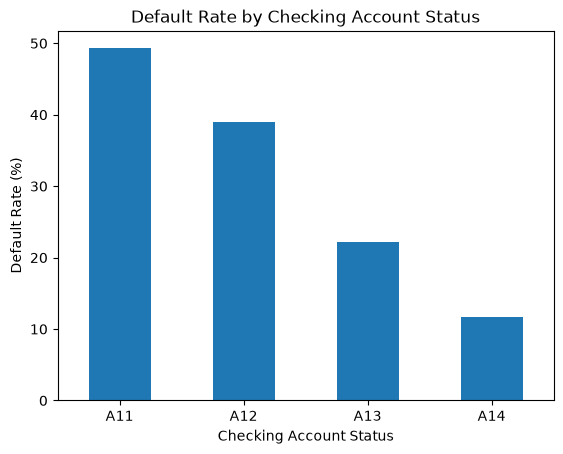

In [38]:
default_by_checking = (
    df.groupby("checking_status")["default"].mean() * 100
)

default_by_checking.plot(kind="bar")

plt.title("Default Rate by Checking Account Status")
plt.xlabel("Checking Account Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# 5. Savings vs Credit Risk

In [39]:
df["savings"].value_counts()

savings
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

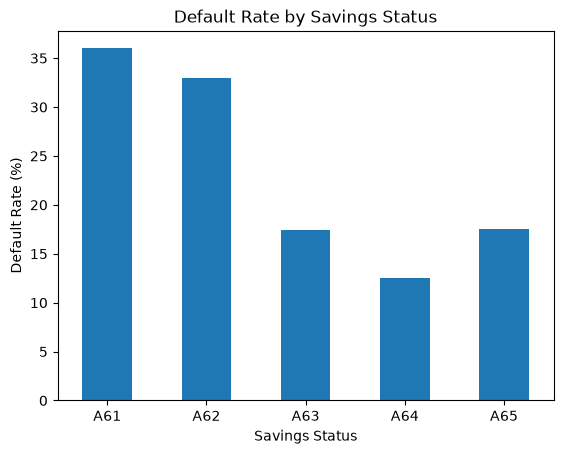

In [40]:
default_by_savings = (
    df.groupby("savings")["default"].mean() * 100
)

default_by_savings.plot(kind="bar")

plt.title("Default Rate by Savings Status")
plt.xlabel("Savings Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# 6. Credit History

In [41]:
df["credit_history"].value_counts()

credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

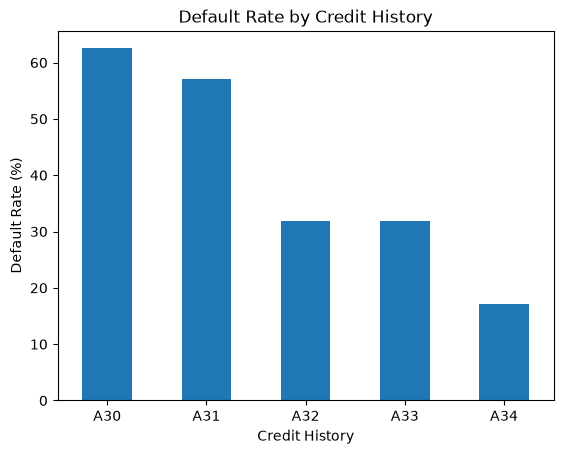

In [42]:
default_by_history = (
    df.groupby("credit_history")["default"].mean() * 100
)

default_by_history.plot(kind="bar")

plt.title("Default Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()